![Screenshot from 2023-12-20 21-06-18.png](<attachment:Screenshot from 2023-12-20 21-06-18.png>)
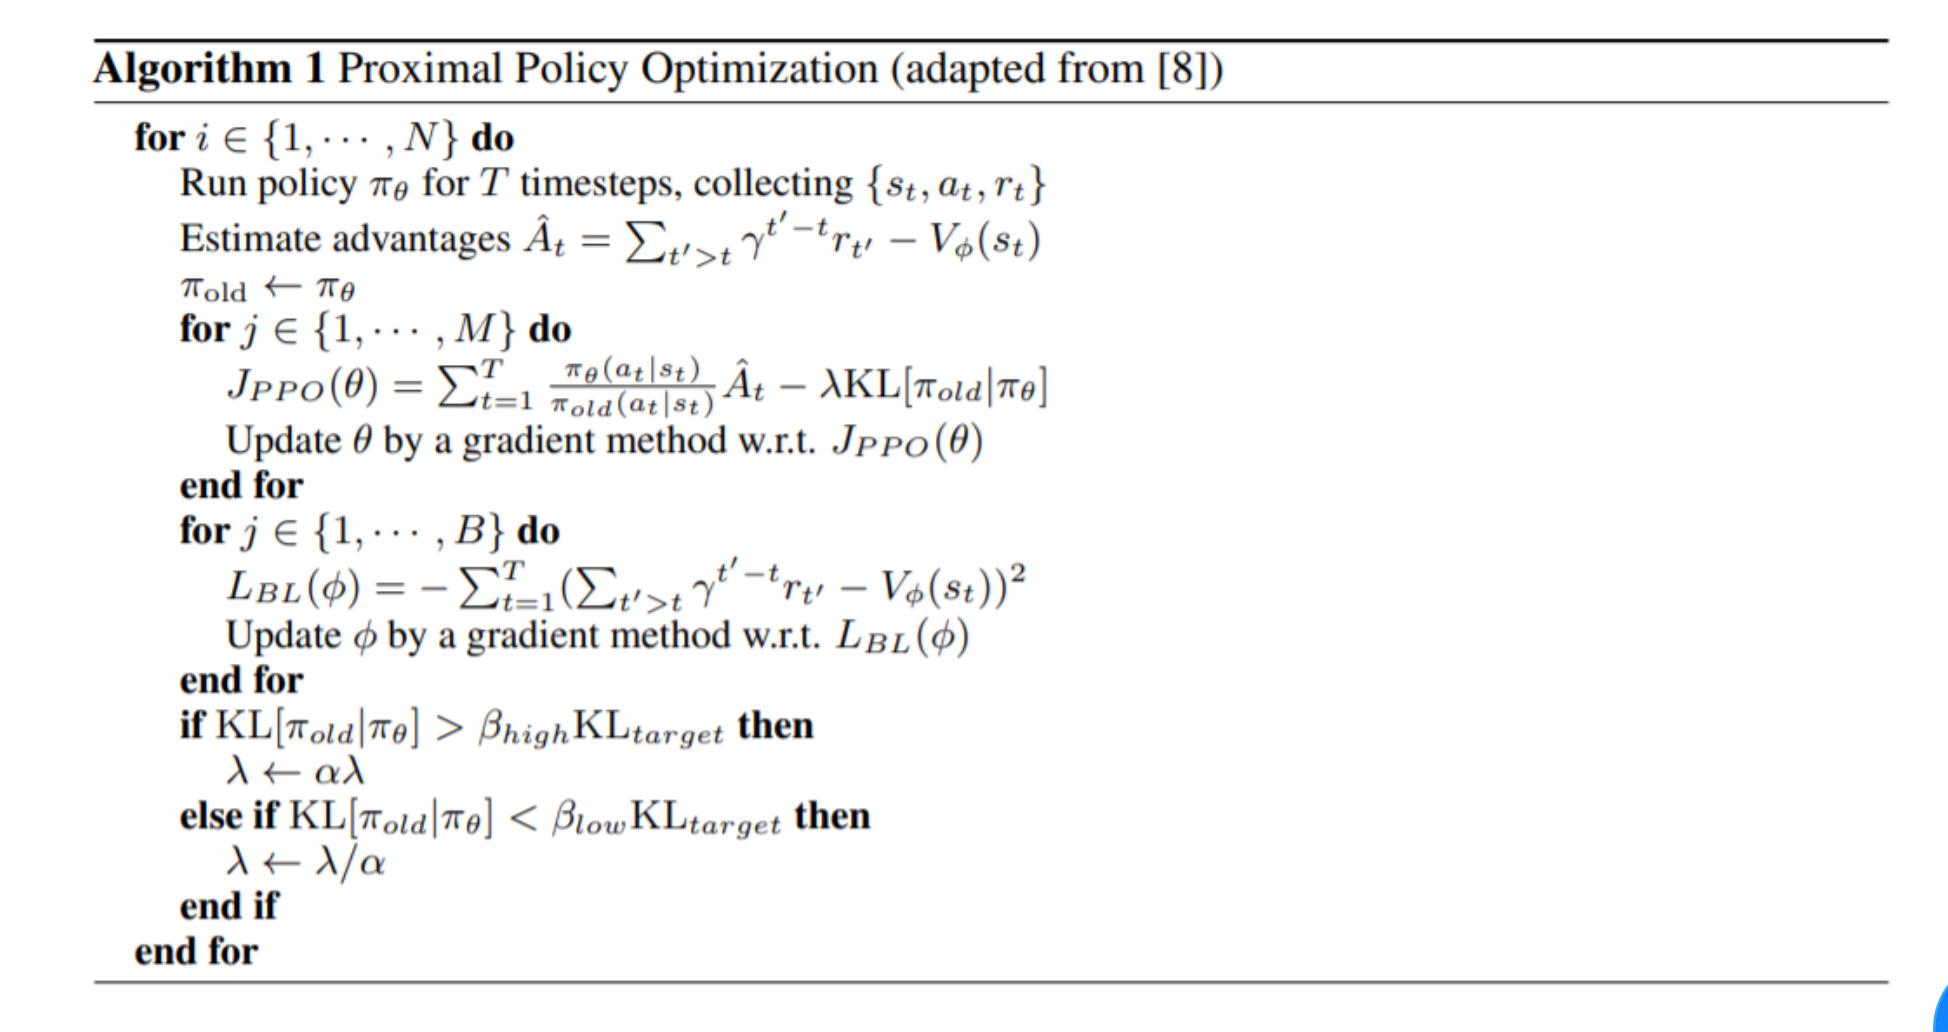

In [1]:
import gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import rl_utils


In [2]:
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=1)


class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

def self_kl_div(P, Q):
    return (P * (P / Q).log()).sum()


In [3]:
class PPO:
    ''' PPO-penalty'''
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda
        self.epochs_m =  epochs_m  # 一条序列的数据用来训练轮数 one trail
        self.epochs_b = epochs_b
        self.beta = beta  # 
        self.kl_constraint = kl_constraint
        self.device = device


    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'],dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        td_target = rewards + self.gamma * self.critic(next_states) * (1 -dones)
        td_delta = td_target - self.critic(states)
        # target critic net---in some way
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda,td_delta.cpu()).to(self.device)
        # same trail given same approximate advantage
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach() #theta_k
        # target actor net --- in some way                     

        with torch.no_grad():
            old_action_dists = torch.distributions.Categorical(self.actor(states))
        #old_action_dist = torch.tensor(self.actor(states)).detach()
            
        for _ in range(self.epochs_m):# one step may not reach the optimal point
            log_probs = torch.log(self.actor(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)
            surr1 = ratio * advantage
           
            curr_action_dists = torch.distributions.Categorical(self.actor(states))
            # curr_action_dist = torch.tensor(self.actor(states))
            curr_kl_div = torch.distributions.kl.kl_divergence(old_action_dists, curr_action_dists)
            #= self_kl_div(curr_action_dist, old_action_dist)
            actor_loss = -torch.mean(surr1 - self.beta * curr_kl_div)   # kl损失函数,注意这里有minus


            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()
                
        
        for _ in range(self.epochs_b):
            critic_loss = torch.mean( F.mse_loss(self.critic(states), td_target.detach()))# td_target using "target net"
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()

        new_action_dists = torch.distributions.Categorical(self.actor(states))
        kl_div = torch.mean(torch.distributions.kl.kl_divergence(old_action_dists, new_action_dists))
        if kl_div < self.kl_constraint / 1.5:
            self.beta /= 2
        if kl_div > 1.5 * self.kl_constraint:
            self.beta *= 2

In [4]:
actor_lr = 1e-3
critic_lr = 1e-2
num_episodes = 500
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs_m = 10
epochs_b = 20
beta = 1
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
kl_constraint = 0.001

env_name = 'CartPole-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

# Iteration 0: 100%|██████████| 50/50 [00:10<00:00,  4.81it/s, episode=50,
# return=183.200]
# Iteration 1: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s, episode=100,
# return=191.400]
# Iteration 2: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s, episode=150,
# return=199.900]
# Iteration 3: 100%|██████████| 50/50 [00:21<00:00,  2.33it/s, episode=200,
# return=200.000]
# Iteration 4: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s, episode=250,
# return=200.000]
# Iteration 5: 100%|██████████| 50/50 [00:22<00:00,  2.22it/s, episode=300,
# return=200.000]
# Iteration 6: 100%|██████████| 50/50 [00:23<00:00,  2.14it/s, episode=350,
# return=200.000]
# Iteration 7: 100%|██████████| 50/50 [00:23<00:00,  2.16it/s, episode=400,
# return=200.000]
# Iteration 8: 100%|██████████| 50/50 [00:22<00:00,  2.23it/s, episode=450,
# return=200.000]
# Iteration 9: 100%|██████████| 50/50 [00:22<00:00,  2.25it/s, episode=500,
# return=200.000]

Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_3533/298808502.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  state = torch.tensor([state], dtype=torch.float).to(self.device)
Iteration 9: 100%|██████████| 50/50 [00:05<00:00,  9.60it/s, episode=500, return=200.000]


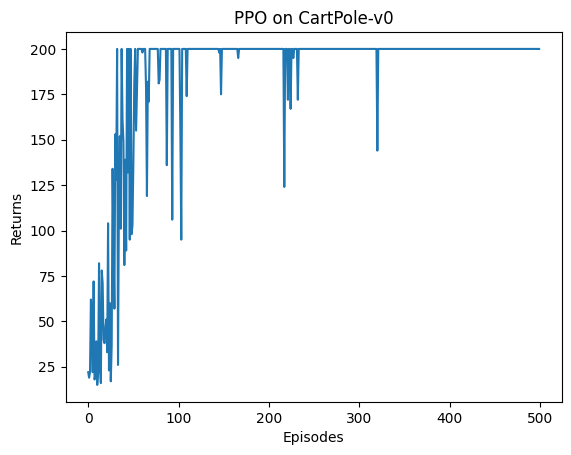

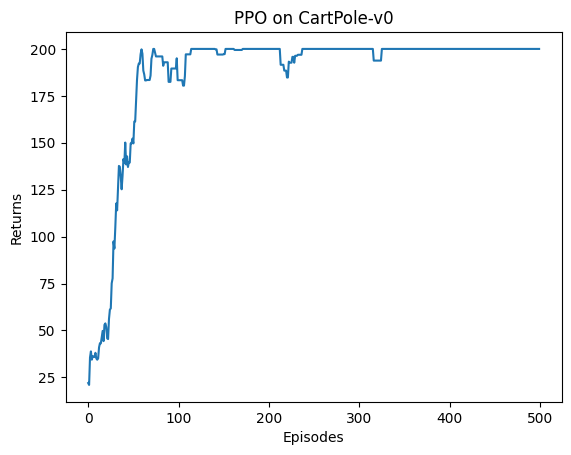

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

In [9]:
class PolicyNetContinuous(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc_mu = torch.nn.Linear(hidden_dim, action_dim)
        self.fc_std = torch.nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = 2.0 * torch.tanh(self.fc_mu(x))
        std = F.softplus(self.fc_std(x))
        return mu, std

class ValueNet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = torch.nn.Linear(state_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [23]:
class PPOContinuous:
    ''' 处理连续动作的PPO算法 '''
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr,  lmbda, kl_constraint, epochs_m, epochs_b, eps, beta, gamma, device, type=0):
        #       (self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device):#
        self.actor = PolicyNetContinuous(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),lr=critic_lr)
        self.gamma = gamma
        self.lmbda = lmbda
        self.kl_constraint = kl_constraint
        self.epochs_m = epochs_m
        self.epochs_b = epochs_b
        self.beta = beta
        self.device = device
        self.type = type
        self.eps = eps

    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        mu, sigma = self.actor(state)
        action_dist = torch.distributions.Normal(mu, sigma)
        action = action_dist.sample()
        return [action.item()]
    
    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float).view(-1, 1).to(self.device)
        rewards = (rewards + 8.0) / 8.0  # 和TRPO一样,对奖励进行修改,方便训练
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_delta = td_target - self.critic(states)
        advantage = rl_utils.compute_advantage(self.gamma, self.lmbda, td_delta.cpu()).to(self.device)

        mu, std = self.actor(states)

        old_action_dists = torch.distributions.Normal(mu.detach(), std.detach())
        # 动作是正态分布

        old_log_probs = old_action_dists.log_prob(actions) #the log probability of observed action in old actor model

        for _ in range(self.epochs_m):# one step may not reach the optimal point
            mu, std = self.actor(states)
            # log_probs = torch.log(self.actor(states).gather(1, actions))
            curr_action_dists = torch.distributions.Normal(mu, std)
            log_probs = curr_action_dists.log_prob(actions)
            ratio = torch.exp(log_probs - old_log_probs)
            surr1 = ratio * advantage          

            if self.type == 0:
                surr2 = torch.clamp(ratio, 1 - self.eps, 1 + self.eps) * advantage
                actor_loss = torch.mean(-torch.min(surr1, surr2))
                self.actor_optimizer.zero_grad()
                actor_loss.backward()
                self.actor_optimizer.step()
            
            if self.type == 1:
            # curr_action_dist = torch.tensor(self.actor(states))
                curr_kl_div = torch.distributions.kl.kl_divergence(old_action_dists, curr_action_dists)
                #= self_kl_div(curr_action_dist, old_action_dist)
                actor_loss = -torch.mean(surr1 - self.beta * curr_kl_div)   # kl损失函数,注意这里有minus
                self.actor_optimizer.zero_grad()
                actor_loss.backward()
                self.actor_optimizer.step()
            
                
        
        for _ in range(self.epochs_b):
            critic_loss = torch.mean( F.mse_loss(self.critic(states), td_target.detach()))# td_target using "target net"
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()
            
        if self.type == 1:
            mu, std = self.actor(states)
                # log_probs = torch.log(self.actor(states).gather(1, actions))
            new_action_dists = torch.distributions.Normal(mu, std)

            kl_div = torch.mean(torch.distributions.kl.kl_divergence(old_action_dists, new_action_dists))
            if kl_div < self.kl_constraint / 1.5:
                self.beta /= 2
            if kl_div > 1.5 * self.kl_constraint:
                self.beta *= 2

In [28]:
actor_lr = 1e-4
critic_lr = 5e-3
num_episodes = 2000
hidden_dim = 128
gamma = 0.9
lmbda = 0.9
epochs_m = 10
epochs_b = 20
beta = 1
eps = 0.2
type = 1 #1: penality; 0: clip
kl_constraint = 0.001
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

env_name = 'Pendulum-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]  # 连续动作空间
agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m,epochs_b, eps, beta, gamma, device, type)
#            (self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, lmbda, kl_constraint, epochs_m, epochs_b, beta, gamma, device)
return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

Iteration 0:   0%|          | 0/200 [00:00<?, ?it/s]

Iteration 9: 100%|██████████| 200/200 [00:21<00:00,  9.18it/s, episode=2000, return=-331.618]


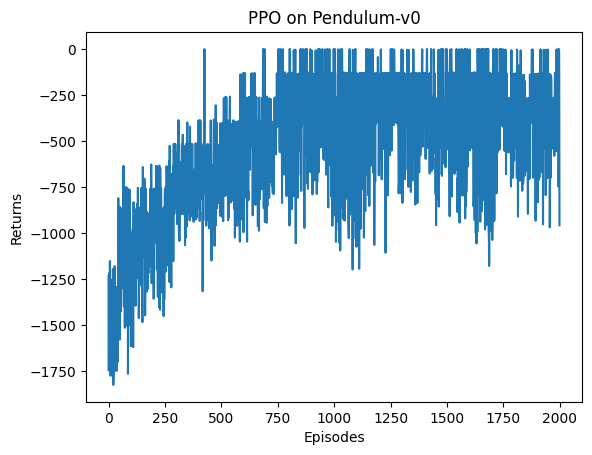

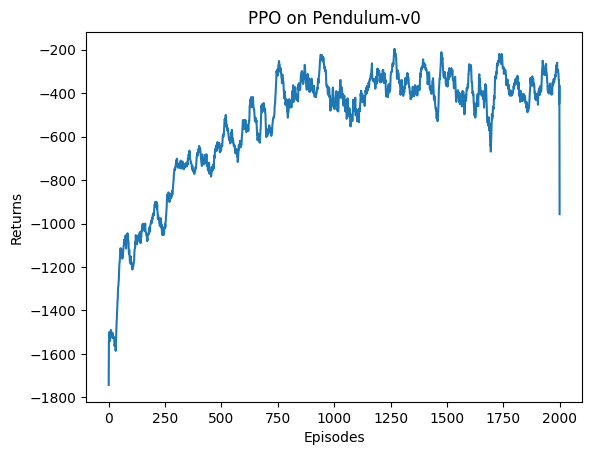

In [29]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 21)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on {}'.format(env_name))
plt.show()